In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [13]:
vect = CountVectorizer(ngram_range=(1, 1))
vect.fit_transform(['nothing is impossible', 'everything is possible']).toarray()

array([[0, 1, 1, 1, 0],
       [1, 0, 1, 0, 1]])

In [14]:
vect.vocabulary_

{'nothing': 3, 'is': 2, 'impossible': 1, 'everything': 0, 'possible': 4}

In [15]:
vect = CountVectorizer(ngram_range=(1, 2))
vect.fit_transform(['nothing is impossible', 'everything is possible']).toarray()

array([[0, 0, 1, 1, 1, 0, 1, 1, 0],
       [1, 1, 0, 1, 0, 1, 0, 0, 1]])

In [16]:
vect.vocabulary_

{'nothing': 6,
 'is': 3,
 'impossible': 2,
 'nothing is': 7,
 'is impossible': 4,
 'everything': 0,
 'possible': 8,
 'everything is': 1,
 'is possible': 5}

# N-граммы из букв

In [17]:
from scipy.spatial.distance import euclidean
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
vect = CountVectorizer(ngram_range=(3, 3), analyzer='char_wb')
n1, n2, n3, n4 = vect.fit_transform(['иванов', 'петров', 'петренко', 'смит']).toarray()
euclidean(n1, n2), euclidean(n2, n3), euclidean(n3, n4)

(np.float64(3.1622776601683795),
 np.float64(2.8284271247461903),
 np.float64(3.4641016151377544))

# Изображения

In [19]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
import numpy as np

In [20]:
resnet_settings = {'include_top': True, 'weights': 'imagenet'}
resnet = ResNet50(**resnet_settings)

img = image.load_img('images.jpeg')
img_array = image.img_to_array(img)

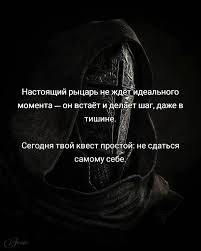

In [21]:
img

In [22]:
img = img.resize((224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

features = resnet.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [23]:
features

array([[4.18144082e-05, 5.08758276e-05, 6.74052426e-05, 1.05361280e-04,
        8.92375829e-05, 1.60052557e-04, 3.81019959e-06, 3.25304791e-05,
        6.92113463e-06, 2.33722203e-05, 3.11280610e-06, 1.07795677e-06,
        2.00441127e-06, 1.01997205e-06, 6.65860580e-06, 2.12374766e-06,
        1.89360583e-06, 1.69373709e-06, 4.80463905e-06, 2.51133497e-06,
        9.10094059e-06, 2.64161031e-06, 1.42982353e-05, 5.46552610e-06,
        1.04410092e-05, 2.97757033e-05, 9.49547757e-05, 3.21374173e-05,
        9.52564096e-06, 2.09001173e-05, 6.26650763e-06, 2.42936608e-06,
        2.34443723e-05, 3.60637423e-05, 2.89439158e-05, 7.94318203e-06,
        1.46029943e-05, 1.09383620e-06, 3.56250639e-05, 1.41765963e-06,
        3.65662299e-06, 1.87551068e-05, 5.66135577e-06, 3.29591385e-05,
        1.74281777e-05, 2.76439878e-05, 1.68450197e-06, 5.36442894e-05,
        1.66761729e-05, 3.53081532e-06, 1.29256281e-04, 3.17778213e-05,
        1.05250212e-04, 5.96037644e-05, 7.82986681e-05, 1.292982

# Чтение текста с картинки

In [24]:
import pytesseract
from PIL import Image
import requests
from io import BytesIO

In [25]:
img = 'http://ohscurrent.org/wp-content/uploads/2015/09/domus-01-google.jpg'
img = requests.get(img)
img = Image.open(BytesIO(img.content))
text = pytesseract.image_to_string(img)
print(text)

KeyboardInterrupt: 

In [ ]:
img = "https://habrastorage.org/webt/mj/uv/6o/mjuv6olsh1x9xxe1a6zjy79u1w8.jpeg"
img = requests.get(img)
img = Image.open(BytesIO(img.content))
text = pytesseract.image_to_string(img)
print(text)

# Временные ряды, веб и прочее

In [28]:
import user_agents

ua = "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Ubuntu Chromium/56.0.2924.76 Chrome/56.0.2924.76 Safari/537.36"
ua = user_agents.parse(ua)

print("Is a bot? ", ua.is_bot)
print("Is mobile? ", ua.is_mobile)
print("Is PC? ", ua.is_pc)
print("OS Family: ", ua.os.family)
print("OS Version: ", ua.os.version)
print("Browser Family: ", ua.browser.family)
print("Browser Version: ", ua.browser.version)

Is a bot?  False
Is mobile?  False
Is PC?  True
OS Family:  Ubuntu
OS Version:  ()
Browser Family:  Chromium
Browser Version:  (56, 0, 2924)


# Нормализация данных

In [37]:
import numpy as np
from scipy.stats import beta, shapiro
from sklearn.preprocessing import StandardScaler

# Z-score normalization
data = beta(1, 10).rvs(1000).reshape(-1, 1)
shapiro(data)

ShapiroResult(statistic=np.float64(0.8771117353254925), pvalue=np.float64(2.302359916815854e-27))

In [42]:
data = np.array([1, 1, 0, -1, 2, 1, 2, 3, -2, 4, 100]).reshape(-1, 1).astype(np.float64)
StandardScaler().fit_transform(data)

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

In [43]:
# Z-score normalization формула
(data - data.mean()) / data.std()

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

In [44]:
from sklearn.preprocessing import MinMaxScaler

In [45]:
MinMaxScaler().fit_transform(data)

array([[0.02941176],
       [0.02941176],
       [0.01960784],
       [0.00980392],
       [0.03921569],
       [0.02941176],
       [0.03921569],
       [0.04901961],
       [0.        ],
       [0.05882353],
       [1.        ]])

In [47]:
# MinMax Scaling формула
(data - data.min()) / (data.max() - data.min())

array([[0.02941176],
       [0.02941176],
       [0.01960784],
       [0.00980392],
       [0.03921569],
       [0.02941176],
       [0.03921569],
       [0.04901961],
       [0.        ],
       [0.05882353],
       [1.        ]])

In [48]:
from scipy.stats import lognorm

In [51]:
# Логнормальное распределение
data = lognorm(s=1).rvs(1000)
shapiro(data)

ShapiroResult(statistic=np.float64(0.5258117472792205), pvalue=np.float64(1.487368953886197e-45))

In [52]:
shapiro(np.log(data))

ShapiroResult(statistic=np.float64(0.9989281194192872), pvalue=np.float64(0.8338731398335782))

# Feature selection

In [55]:
# Статистические подходы

from sklearn.datasets import make_classification
from sklearn.feature_selection import VarianceThreshold

x_data_generated, y_data_generated = make_classification()
x_data_generated.shape

(100, 20)

In [56]:
VarianceThreshold(0.7).fit_transform(x_data_generated).shape

(100, 19)

In [57]:
VarianceThreshold(0.8).fit_transform(x_data_generated).shape

(100, 18)

In [58]:
VarianceThreshold(0.9).fit_transform(x_data_generated).shape

(100, 14)

In [59]:
# Отбор с использованием моделей

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

In [60]:
x_data_generated, y_data_generated = make_classification()

pipe =  make_pipeline(SelectFromModel(estimator=RandomForestClassifier()), LogisticRegression())
lr = LogisticRegression()
rf = RandomForestClassifier()

print(cross_val_score(lr, x_data_generated, y_data_generated, scoring='neg_log_loss').mean())
print(cross_val_score(rf, x_data_generated, y_data_generated, scoring='neg_log_loss').mean())
print(cross_val_score(pipe, x_data_generated, y_data_generated, scoring='neg_log_loss').mean())

-0.49039673975235587
-0.3420948201184329
-0.3809324554903487


In [61]:
x_data = x_data_generated
y_data = y_data_generated

pipe1 = make_pipeline(StandardScaler(), SelectFromModel(estimator=RandomForestClassifier()), LogisticRegression())
pipe2 = make_pipeline(StandardScaler(), LogisticRegression())

rf = RandomForestClassifier()

print("LR + selection: ", cross_val_score(pipe1, x_data, y_data, scoring='neg_log_loss').mean())
print("LR: ", cross_val_score(pipe2, x_data, y_data, scoring='neg_log_loss').mean())
print("RF: ", cross_val_score(rf, x_data, y_data, scoring='neg_log_loss').mean())

LR + selection:  -0.371594239305957
LR:  -0.4836154818445976
RF:  -0.34319999163989634


In [65]:
# перебор
# самый надежный, но и вычислительно затратный метод
from mlxtend.feature_selection import SequentialFeatureSelector

In [66]:
selector =  SequentialFeatureSelector(LogisticRegression(),
                                      scoring='neg_log_loss',
                                      verbose=2,
                                      k_features=3,
                                      forward=False,
                                      n_jobs=-1)

selector.fit(x_data, y_data)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:    1.8s remaining:    3.3s
[Parallel(n_jobs=-1)]: Done  18 out of  20 | elapsed:    2.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    2.1s finished

[2026-06-10 13:19:30] Features: 19/3 -- score: -0.4540737528122666[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  19 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  14 out of  19 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed:    0.1s finished

[2026-06-10 13:19:30] Features: 18/3 -- score: -0.42689480232987204[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  18 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  13 out of  18 | elapsed:    0.0s remaining:    0.0s
[Paral

,estimator,LogisticRegression()
,k_features,"(3, ...)"
,forward,False
,floating,False
,verbose,2
,scoring,'neg_log_loss'
,cv,5
,n_jobs,-1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None
